# Predicted TX spectrum

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import tx_model as tx
from tx_model import (FS_DAC, F_NCO, F_CARRIER, COMPARE_RATES, LFSR_TAPS,
                      mseq, rrc_taps, periodic_baseband, occupied_bw,
                      h_nrz, h_mix, board_loss_db, cw_ideal_dbm,
                      dac_output_lines, analyzer_trace, simulate, image_power,
                      plot_full_span, plot_chip_rate_compare, plot_fine_comb, print_summary)

In [10]:
plt.rcParams['font.size'] = '20';plt.rcParams['font.style'] = 'normal'
plt.rcParams['font.weight'] = 'normal';plt.rcParams['axes.grid'] = True;plt.rcParams['grid.linestyle'] = '-';
plt.rcParams['grid.linewidth'] = 0.4;plt.rcParams['grid.color'] = "Black";plt.rcParams['grid.alpha'] = 1;
plt.rcParams['lines.linewidth'] = 3;#plt.rcParams['axes.autolimit_mode'] = 'round_numbers';plt.rcParams['axes.axisbelow'] = True
plt.rcParams['xtick.direction'] = 'in';plt.rcParams['ytick.direction'] = 'in';plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 0.5;plt.rcParams['ytick.major.width'] = 1;plt.rcParams['ytick.minor.width'] = 0.5;
plt.rcParams['xtick.major.size'] = 4;plt.rcParams['xtick.minor.size'] = 2;plt.rcParams['ytick.major.size'] = 4;
plt.rcParams['ytick.minor.size'] = 2; plt.rcParams['svg.fonttype'] = 'none'; #cs = list(mcolors.TABLEAU_COLORS.values())
plt.rcParams['axes.linewidth']=1;plt.rcParams['xtick.top'] = True;plt.rcParams['ytick.right'] = True;
plt.rcParams['axes.spines.top'] = True;plt.rcParams['axes.spines.bottom'] = True;plt.rcParams['axes.spines.left'] = True;
plt.rcParams['axes.spines.right'] = True# Plot Appearance Settings

### 1. Linear Feedback Shift Register

length: 1023, ones: 512, zeros: 511, difference: 1


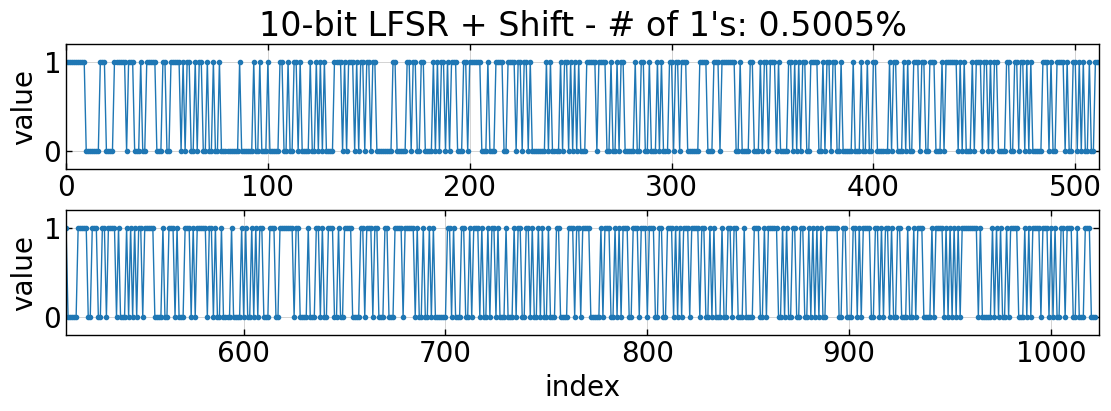

In [43]:
seq = mseq(10)
n_ones = int(np.count_nonzero(seq == 1))
n_zeros = int(np.count_nonzero(seq == 0))
print(f"length: {seq.size}, ones: {n_ones}, zeros: {n_zeros}, difference: {n_ones - n_zeros}")


fig, ax = plt.subplots(2, 1,figsize=(11, 4), layout = 'constrained')
ax[0].plot(seq, marker='o', ms=3, lw=1)
ax[0].set(ylabel="value",
       title=f"10-bit LFSR + Shift - # of 1's: {n_ones/(n_ones+n_zeros):.4f}%",
       xlim=(0, 512), ylim=(-0.2, 1.2))
ax[0].grid(alpha=0.3)
ax[1].plot(seq, marker='o', ms=3, lw=1)
ax[1].set(ylabel="value", xlabel='index',
       xlim=(512, 1024), ylim=(-0.2, 1.2))
ax[1].grid(alpha=0.3)

### 2. Root-Raised-Cosine (RRC) Pulse Shaping

Same chain as `periodic_baseband()`: bits → BPSK chips → upsample → RRC filter.
The RX applies the same RRC again (matched filter): RRC × RRC = raised cosine, which has zero ISI at the chip instants.

#### 2a. BPSK mapping and upsampling

Bits 0/1 become chips +1/−1. Then each chip is placed at the start of `SPS` samples, with zeros in between: a train of impulses the filter will turn into pulses.

In [ ]:
NBITS     = 10             # LFSR length; PRN period = 2^NBITS - 1 chips
CHIP_RATE = FS_DAC / 96    # chips/s (51.2 Mcps)
BETA      = 0.35           # RRC roll-off
PEAK_AMP  = 0.5            # waveform peak, same scale as DAC gain (0.5 = bench tone)
SPS  = 8       # samples per chip
SPAN = 16      # RRC filter length in chips
N_SHOW = 30    # chips shown in the time-domain plots

fs_bb = SPS * CHIP_RATE                   # baseband sample rate
seq = mseq(NBITS)

chips = 1.0 - 2.0 * seq                   # 0 -> +1, 1 -> -1
up = np.zeros(chips.size * SPS)
up[::SPS] = chips                         # one chip every SPS samples, zeros between
n = np.arange(N_SHOW * SPS)               # sample indices shown

fig, ax = plt.subplots(2, 1, figsize=(11, 7), layout='constrained', sharex=True)
ax[0].step(np.arange(N_SHOW + 1), np.append(chips[:N_SHOW], chips[N_SHOW - 1]), where="post", lw=2)
ax[0].set(ylabel="chip", title=f"BPSK chips (first {N_SHOW})", ylim=(-1.5, 1.5))
ax[0].grid(alpha=0.3)
ax[1].stem(n / SPS, up[:N_SHOW * SPS], basefmt=" ")
ax[1].set(ylabel="value", xlabel="time [chips]", title=f"Upsampled, {SPS} samples/chip", ylim=(-1.5, 1.5))
ax[1].grid(alpha=0.3)

#### 2b. The RRC filter

Top: impulse response (it does *not* cross zero at every chip, only RRC × RRC does).
Bottom: frequency response. Dotted lines at (1−β)Rc/2, Rc/2, (1+β)Rc/2: flat below the first, −6 dB (RC) at the middle, zero beyond the last.

In [ ]:
h = rrc_taps(BETA, SPS, SPAN)
th = (np.arange(h.size) - h.size // 2) / SPS          # time in chips, centered on 0

NFFT = 8192
f = np.fft.fftshift(np.fft.fftfreq(NFFT, 1 / fs_bb))
H = np.fft.fftshift(np.abs(np.fft.fft(h, NFFT)))
H /= H.max()
edges = [(1 - BETA) * CHIP_RATE / 2, CHIP_RATE / 2, (1 + BETA) * CHIP_RATE / 2]
print("band edges [MHz]:", [round(e / 1e6, 2) for e in edges])

fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].plot(th, h, marker='o', ms=3, lw=1)
ax[0].set(xlabel="time [chips]", ylabel="h", title=f"RRC impulse response, beta={BETA}, {h.size} taps")
ax[0].grid(alpha=0.3)
ax[1].plot(f / 1e6, 20 * np.log10(H + 1e-12), lw=2, label="RRC")
ax[1].plot(f / 1e6, 20 * np.log10(H ** 2 + 1e-12), lw=2, label="RRC x RRC")
for e in edges:
    ax[1].axvline(e / 1e6, color="k", ls=":", lw=1.5)
ax[1].set(xlabel="frequency [MHz]", ylabel="|H| [dB]", title="Frequency response",
          xlim=(0, 1.5 * CHIP_RATE / 1e6), ylim=(-80, 5))
ax[1].legend(fontsize=14); ax[1].grid(alpha=0.3)

#### 2c. Filtering the chips

Circular convolution, because the PRN repeats with no gaps. The filter delays the signal by half its length; that is undone so the pulses line up with the chips.
Top: at the chip instants (dots) the values wander around ±0.3. That is ISI from the TX filter alone.
Bottom: spectrum before (flat impulses) and after (confined to ±Rc(1+β)/2).

In [ ]:
shaped = np.real(np.fft.ifft(np.fft.fft(up) * np.fft.fft(h, up.size)))
delay = h.size // 2                                   # filter delay in samples (half the taps)
shaped = np.roll(shaped, -delay)                      # undo the delay so chips line up
shaped *= PEAK_AMP / np.max(np.abs(shaped))           # same peak scaling as periodic_baseband

Pu = np.fft.fftshift(np.abs(np.fft.fft(up)) ** 2)
Ps = np.fft.fftshift(np.abs(np.fft.fft(shaped)) ** 2)
fu = np.fft.fftshift(np.fft.fftfreq(up.size, 1 / fs_bb))
print(f"occupied BW ~ Rc(1+beta) = {CHIP_RATE * (1 + BETA) / 1e6:.1f} MHz")

fig, ax = plt.subplots(2, 1, figsize=(11, 8), layout='constrained')
ax[0].step(np.arange(N_SHOW + 1), PEAK_AMP * np.append(chips[:N_SHOW], chips[N_SHOW - 1]),
           where="post", lw=1, alpha=0.5, label="chips")
ax[0].plot(n / SPS, shaped[:N_SHOW * SPS], lw=2, label="RRC-shaped")
ax[0].plot(n[::SPS] / SPS, shaped[:N_SHOW * SPS:SPS], 'o', ms=6, label="chip instants")
ax[0].set(xlabel="time [chips]", ylabel="amplitude", title="Shaped waveform (TX)")
ax[0].legend(fontsize=12, loc="upper right"); ax[0].grid(alpha=0.3)
ax[1].plot(fu / 1e6, 10 * np.log10(Pu / Pu.max() + 1e-15), lw=0.5, label="before RRC")
ax[1].plot(fu / 1e6, 10 * np.log10(Ps / Ps.max() + 1e-15), lw=0.5, label="after RRC")
ax[1].set(xlabel="baseband frequency [MHz]", ylabel="power [dB]", title="Spectrum", ylim=(-80, 5))
ax[1].legend(fontsize=12, loc="lower right"); ax[1].grid(alpha=0.3)

# check: same waveform as periodic_baseband(), up to the filter delay
b, _, _ = periodic_baseband(CHIP_RATE, BETA, nbits=NBITS, sps=SPS, span=SPAN, peak_amp=PEAK_AMP)
print("matches periodic_baseband:", np.allclose(np.roll(b, -delay), shaped))

#### 2d. Eye diagrams: why RRC on both ends

Overlay 2-chip slices centered on each chip instant. After the TX RRC alone the eye is blurred (ISI).
After the RX matched RRC (RRC × RRC = raised cosine) every trace passes through ±1 at the chip instant: zero ISI.
The small leftover spread comes from truncating the filter to `SPAN` chips.

In [ ]:
rx = np.real(np.fft.ifft(np.fft.fft(shaped) * np.fft.fft(h, shaped.size)))
rx = np.roll(rx, -delay)                              # undo the second filter delay
rx /= np.mean(np.abs(rx[::SPS]))                      # normalize: chip instants at +/-1
tx_n = shaped / np.mean(np.abs(shaped[::SPS]))
print(f"spread at chip instants: TX {np.ptp(np.abs(tx_n[::SPS])):.3f}, RX {np.ptp(np.abs(rx[::SPS])):.3f}")

te = np.arange(-SPS, SPS + 1) / SPS                   # 2 chips wide, centered on a chip instant
fig, ax = plt.subplots(1, 2, figsize=(11, 5), layout='constrained', sharey=True)
for k in range(2, 200):
    i = k * SPS
    ax[0].plot(te, tx_n[i - SPS:i + SPS + 1], "C0", lw=0.5, alpha=0.4)
    ax[1].plot(te, rx[i - SPS:i + SPS + 1], "C1", lw=0.5, alpha=0.4)
ax[0].set(xlabel="time [chips]", ylabel="amplitude", title="TX (RRC)")
ax[1].set(xlabel="time [chips]", title="RX (RRC x RRC)")
for a in ax:
    a.grid(alpha=0.3)